# Setup and download - IMC Type 1 Diabetes Pancreas data

This tutorials shows how to set up an multiple slide spatial proteomics (IMC) dataset used from [Damond et al., 2019](https://doi.org/10.1016/j.cmet.2018.11.014). To follow along with this and the following tutorials, please execute the following steps first:

- Set up InterScale environment (see instructions in ReadMe)
- Download the sample data from the original publication from [Zenodo](https://zenodo.org/records/13907274)

In [1]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse
import seaborn as sns

from pathlib import Path

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Imp

In [2]:
from pathlib import Path

# set INTERSCALE_DIR to the current working directory
INTERSCALE_DIR = Path.cwd()
print(INTERSCALE_DIR)

/workspace


<mark>TODO: Change data path</mark>

In [2]:
LRZ_IMC_PANCREAS = '/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/data/spatial_proteomics_pancreas_t1d_IMC.h5ad'  
HPC_IMC_PANCREAS = '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/imc_pancreas.h5ad'

## Load data

In [3]:
adata_pancreas = sc.read_h5ad(HPC_IMC_PANCREAS)
adata_pancreas

AnnData object with n_obs × n_vars = 1776974 × 38
    obs: 'ImageNumber', 'ObjectNumber', 'Location_Center_X', 'Location_Center_Y', 'Number_Object_Number', 'image_name', 'id', 'CellCat', 'CellType', 'case', 'slide', 'part', 'group', 'stage', 'duration', 'Aab status', 'Age', 'Gender', 'Ethnicity', 'BMI'
    uns: 'morphology', 'neighbors', 'parent_structure'
    obsm: 'spatial'
    layers: 'MeanIntensity', 'MedianIntensity'

In [50]:
print('Nr. of donors: ', len(np.unique(adata_pancreas.obs['case'])))

Nr. of donors:  12


## 1. Normalization

The data needs to be normalized for InterScale. Check if the data is already normalized: 

In [4]:
print(f'Min count: {adata_pancreas.X.min()}, Max count: {adata_pancreas.X.max()}')

Min count: 0.0, Max count: 98518.4583556652


In [5]:
for layer_name in ['MeanIntensity', 'MedianIntensity']:
    print(f'Min count: {adata_pancreas.layers[layer_name].min()}, Max count: {adata_pancreas.layers[layer_name].max()}')

Min count: 0.0, Max count: 2526.1143168119283
Min count: 0.0, Max count: 1220.530029296875


The data is not yet normalized, so normalize like described in the publication: "raw IMC counts were 99th-percentile-normalized and scaled from 0 to 1 (scaled counts)."

In [6]:
percentile_99 = np.percentile(adata_pancreas.X, 99, axis=0)
pct_norm_99 = adata_pancreas.X / percentile_99
adata_pancreas.layers["pct-norm-99"] = np.clip(pct_norm_99, 0, 1)

In [7]:
print(f'Min count: {adata_pancreas.layers["pct-norm-99"].min()}, Max count: {adata_pancreas.layers["pct-norm-99"].max()}')

Min count: 0.0, Max count: 1.0


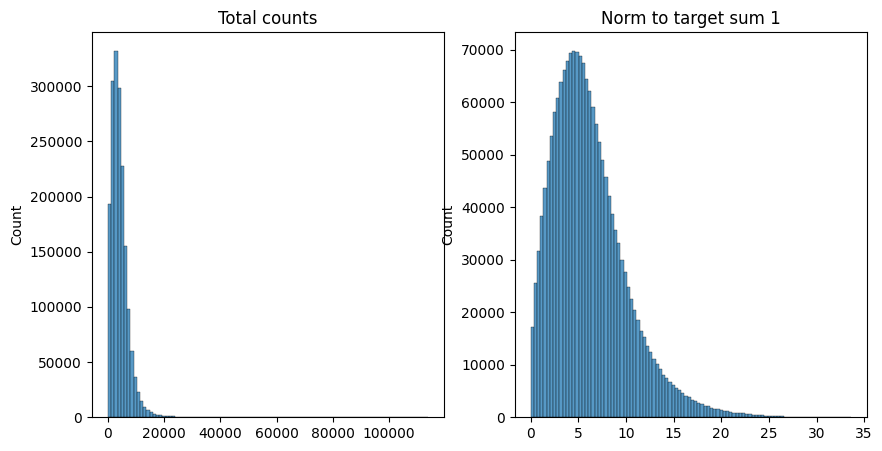

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata_pancreas.X.sum(1), bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata_pancreas.layers["pct-norm-99"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Norm to target sum 1")
plt.show()

## 2. Calculate spatial connectivity matrix

Use [`squidpy.gr.spatial_neighbors()`](https://squidpy.readthedocs.io/en/stable/api/squidpy.gr.spatial_neighbors.html)) to calculate the spatial connectivity. For image-based ST it is important to set `coord_type='generic'`. In Squidpy, you have the option between k-nearest neighbors, delaunay and radius based neighborhood. For InterScale, we use a `radius`-based neighborhood to capture density information. Find the radius for which the number of connected neighbors is approximately 10-30, depending on tissue density. 

In [9]:
print('Nr. of images', len(np.unique(adata_pancreas.obs['ImageNumber'])))

Nr. of images 845


In [10]:
adata_pancreas.obs['ImageNumber'] = pd.Categorical(adata_pancreas.obs['ImageNumber'])

In [11]:
sq.gr.spatial_neighbors(
    adata_pancreas,
    coord_type = "generic",
    library_key = "ImageNumber",
    radius = 30,
)

In [12]:
# Calculate nr. of neighbors per cells
conn = adata_pancreas.obsp['spatial_connectivities']
# Print average number of connections per node
avg_connections = conn.nnz / conn.shape[0]  # total connections / number of nodes
print(f"Average number of connections per node: {avg_connections:.2f}")

Average number of connections per node: 25.22


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


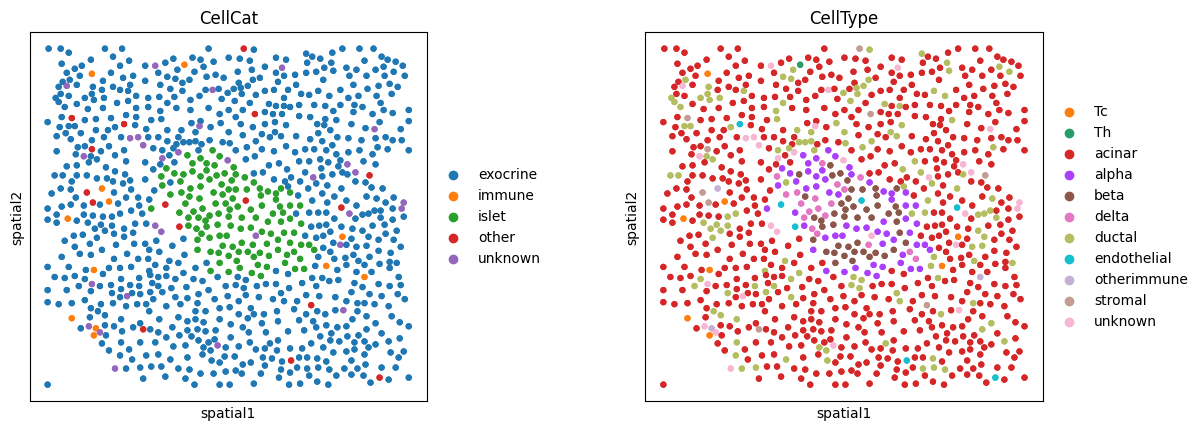

In [13]:
sq.pl.spatial_scatter(
            adata_pancreas,
            color = ['CellCat','CellType'],
            spatial_key = 'spatial',
            library_key='image_name',
            library_id=['M25'],
            shape= None,
            size=50
)

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


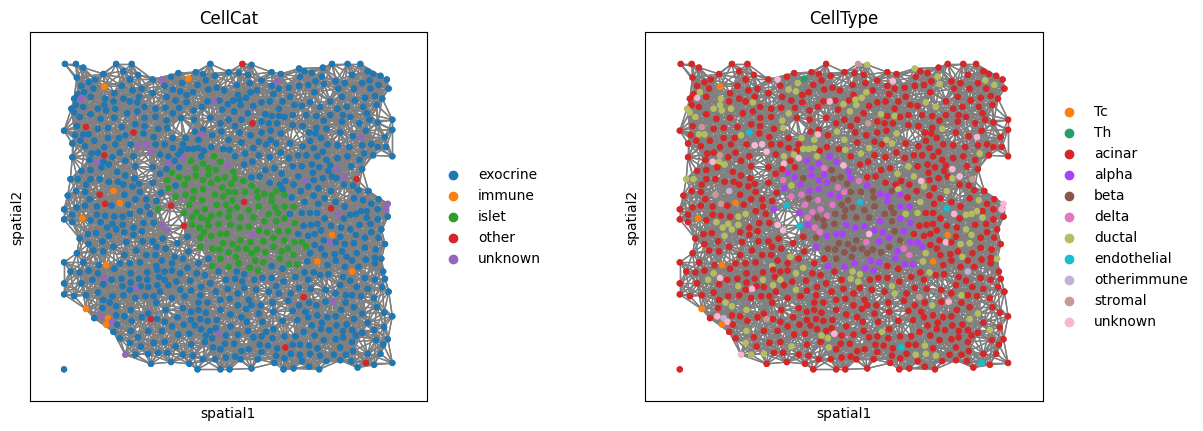

In [14]:
sq.pl.spatial_scatter(
            adata_pancreas,
            color = ['CellCat','CellType'],
            spatial_key = 'spatial',
            library_key='image_name',
            library_id=['M25'],
            shape= None,
            connectivity_key="spatial_connectivities",
            size=50
)

## 3. Optional: Calculate sliding windows

Sliding windows are necessary in case the tissue slide contains more than 4k cells. First, check how many cells are at minimum or maximum in your dataset.

In [15]:
tissue_cell_number = adata_pancreas.obs.groupby('ImageNumber').size()
print(f"Nr cells per sliding window: Min: {tissue_cell_number.min()}, Max: {tissue_cell_number.max()}, Avg: {tissue_cell_number.mean()}")

Nr cells per sliding window: Min: 521, Max: 9396, Avg: 2102.9278106508877


/localscratch/francesca.drummer/ipykernel_3097974/3524064332.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tissue_cell_number = adata_pancreas.obs.groupby('ImageNumber').size()


Select images that have more than some MAX number of cells.

In [16]:
MAX_CELLS = 2500
tissue_cell_number = adata_pancreas.obs.groupby('ImageNumber').size()
batches_high_nr_cells = tissue_cell_number[tissue_cell_number > MAX_CELLS]
print(batches_high_nr_cells)

ImageNumber
1      4650
4      7147
5      3391
6      2518
7      3155
       ... 
837    2549
839    2836
840    3596
843    2980
844    3633
Length: 242, dtype: int64


/localscratch/francesca.drummer/ipykernel_3097974/1254649840.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tissue_cell_number = adata_pancreas.obs.groupby('ImageNumber').size()


We observe that there are a slides with only a few cells but 2 slides with more than 4k cells. For this case we have the option to 1) increase the context length to max = 4875 or 2) calculate sliding windows for all slides that have more than 3k cells. 

In [17]:
# Use the index of batches_high_nr_cells to get the image numbers
sub_adata = adata_pancreas[adata_pancreas.obs['ImageNumber'].isin(batches_high_nr_cells.index)]
sub_adata

View of AnnData object with n_obs × n_vars = 893704 × 38
    obs: 'ImageNumber', 'ObjectNumber', 'Location_Center_X', 'Location_Center_Y', 'Number_Object_Number', 'image_name', 'id', 'CellCat', 'CellType', 'case', 'slide', 'part', 'group', 'stage', 'duration', 'Aab status', 'Age', 'Gender', 'Ethnicity', 'BMI'
    uns: 'morphology', 'neighbors', 'parent_structure', 'spatial_neighbors', 'CellCat_colors', 'CellType_colors'
    obsm: 'spatial'
    layers: 'MeanIntensity', 'MedianIntensity', 'pct-norm-99'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [18]:
print(f"Nr cells per for large images: Min: {batches_high_nr_cells.min()}, Max: {batches_high_nr_cells.max()}, Avg: {batches_high_nr_cells.mean()}")

Nr cells per for large images: Min: 2502, Max: 9396, Avg: 3692.99173553719


In [19]:
sq.tl.sliding_window(
    adata=sub_adata,
    library_key="ImageNumber",  # to stratify by sample
    window_size=600,
    overlap=0,
    copy=False,  # we modify in place
)

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/gr/_utils.py:203: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  obj[key] = data


In [20]:
window_size = sub_adata.obs.groupby('sliding_window_assignment').size()
print(f"Nr cells per sliding window: Min: {window_size.min()}, Max: {window_size.max()}, Avg: {window_size.mean()}")

Nr cells per sliding window: Min: 2, Max: 4606, Avg: 1616.1012658227849


/localscratch/francesca.drummer/ipykernel_3097974/1767285025.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  window_size = sub_adata.obs.groupby('sliding_window_assignment').size()


In [21]:
sub_adata.obs["ImageNumber"]

0            1
1            1
2            1
3            1
4            1
          ... 
1775785    844
1775786    844
1775787    844
1775788    844
1775789    844
Name: ImageNumber, Length: 893704, dtype: category
Categories (242, int64): [1, 4, 5, 6, ..., 839, 840, 843, 844]

With the sliding windows the maximum number of cells per sliding window is `2418`. 

<mark>TODO: Adjust max_seq_len in config file!</mark>
Given this we adjust the `max_seq_len` from the model.global_component to `2418`. The default is `2000`.

In [22]:
del sub_adata.uns['sliding_window_assignment_colors']

KeyError: 'sliding_window_assignment_colors'

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


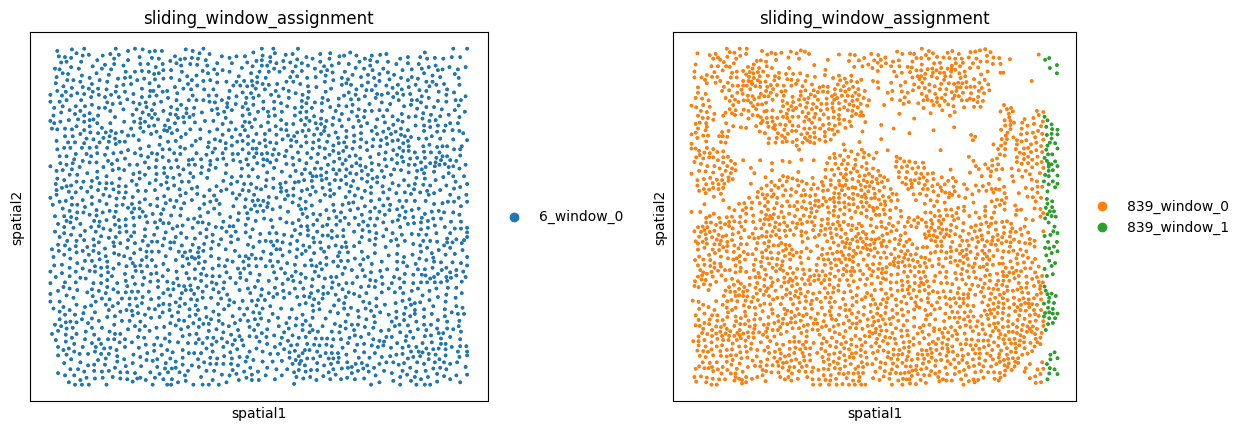

In [23]:
sq.pl.spatial_scatter(
    sub_adata[sub_adata.obs['ImageNumber'].isin([839, 6])],
    spatial_key = 'spatial',
    library_key='ImageNumber', 
    #library_id = [839, 6],
    color="sliding_window_assignment", #cell_type_coarse",
    shape= None,
    size = 10,
)

Add sliding window assignments to full dataset.

In [41]:
max_image_number = adata_pancreas.obs['ImageNumber'].astype(int).max()

# Renumber sliding_window_assignments in sub_adata starting from max_image_number + 1
unique_assignments = sub_adata.obs['sliding_window_assignment'].unique()
assignment_mapping = {old: new for old, new in zip(
    sorted(unique_assignments), 
    range(max_image_number + 1, max_image_number + 1 + len(unique_assignments))
)}

# Create a renumbered version
sub_adata.obs['sliding_window_assignment_renumbered'] = sub_adata.obs['sliding_window_assignment'].map(assignment_mapping)

# Initialize with ImageNumber
adata_pancreas.obs['sliding_window_assignment'] = adata_pancreas.obs['ImageNumber'].astype(int).copy()
mask = adata_pancreas.obs['ImageNumber'].isin(batches_high_nr_cells.index)
adata_pancreas.obs.loc[mask, 'sliding_window_assignment'] = sub_adata.obs['sliding_window_assignment_renumbered'].values

ImageNumber range: 1 - 845
Sliding window assignment range: 2 - 1398
Unique sliding window assignments: [   2    3    9 ... 1396 1397 1398]


In [45]:
window_size = adata_pancreas.obs.groupby('sliding_window_assignment').size()
print(f"Nr cells per sliding window: Min: {window_size.min()}, Max: {window_size.max()}, Avg: {window_size.mean()}")

Nr cells per sliding window: Min: 2, Max: 4606, Avg: 1537.174740484429


## 4. Split data into train and val set

Training the model requires a `split` assignment for each donor/patient/sliding window that you wanna train on. 

In [46]:
from sklearn.model_selection import train_test_split

In [52]:
df = pd.DataFrame({
    'sliding_window_assignment': adata_pancreas.obs['sliding_window_assignment'],
    'batch': adata_pancreas.obs['case']
})


X_train, X_test, y_train, y_test = train_test_split(
    df['sliding_window_assignment'],  # Features (sliding window assignments)
    df['batch'],                       # Target (batch) - used for stratification
    test_size=0.2,                     # Adjust this ratio as needed (80/20 split by default)
    stratify=df['batch'],              # Stratify based on batch column
    random_state=42                    # For reproducibility
)

# Create a new column in the DataFrame to indicate train/test assignment
df['split'] = 'train'  # Initialize all as train
df.loc[X_test.index, 'split'] = 'val'  # Mark test indices

# Alternatively, if you want to add this back to your adata object:
adata_pancreas.obs['split'] = df['split']

In [54]:
adata_pancreas.obs['split']

0          train
1            val
2            val
3          train
4          train
           ...  
1776969    train
1776970    train
1776971      val
1776972      val
1776973    train
Name: split, Length: 1776974, dtype: object

## Save adata object

Save the prepared adata object such that it can be loaded for the model training. 

In [33]:
adata_breast.write('/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/data/visium_tme_pp.h5ad'  )

## Prepare config file

Duplicate the minum requirement config file from `/GT-long-range-niches/src/config_files/InterScale_example.yaml` and add the necessary specification for the Visum data:

```
model:
  local_component:
    name: GCN
  global_component:
    name: self-attn-transformer
        max_seq_len: 2418
  save: /path/to/save/model/
dataset:
  h5ad_data: visium_tme_pp.h5ad
  name: Visium_breast_cancer_TME
  sample_key: ['batch']
  spatial_neigbors_kwargs:
    coord_type: grid
    library_key: batch
```


Save the config file as `.yaml` and proceed to training (either interactively in jupyter notebook or by running a script).